<h1 style="text-align: center;">[Your Project Title]</h1>
<h3 style="text-align: center;">[Your Name]</h3>

---

## **Section 0. Setup**

> 🎯 *Tujuan:* Menyiapkan environment kerja (import library, konfigurasi global) supaya proses selanjutnya konsisten dan reproducible.

**0.1 Import Library**

> 🎯 *Tujuan:* Memuat semua library yang dibutuhkan di satu tempat di awal, supaya dependency notebook mudah dilacak.

In [51]:
# import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# tambahkan import lain sesuai kebutuhan (sklearn, dll) di sini

**0.2 Global Configuration**

> 🎯 *Tujuan:* Menetapkan parameter global seperti random_state di satu tempat, supaya semua proses (split, model, CV) memakai nilai yang sama.

> 📌 **Catatan untuk Peserta:** Selalu set `RANDOM_STATE` di satu tempat dan pakai variabel yang sama di semua proses (train_test_split, model, cross-validation). Ini membuat hasil eksperimenmu **reproducible** — orang lain (atau kamu sendiri, minggu depan) bisa menjalankan ulang notebook dan dapat hasil yang sama persis.

In [50]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

df =  pd.read_csv(r"..\data\raw\data_bank_marketing_campaign.csv")

## **Section 1. Business Understanding**

> 🎯 *Tujuan:* Menerjemahkan masalah bisnis menjadi masalah yang bisa diselesaikan dengan machine learning, sebelum menyentuh data sama sekali.

**1.1 Context**

> 🎯 Bank merupakan salah satu Lembaga keuangan yang menawarkan berbagai produk kepada Masyarakat, seperti Tabungan, kredit, investasi, dan deposito berjangka (term deposit). Salah satu produk investasi yang banyak ditawarkan adalah deposito berjangka, yaitu simpanan yang hanya dapat cair stelah jangka waktu tertentu dengan memberi hasil berupa bunga tetap.
Dalam industri perbankan yang semakin kompetitif, mempertahankan nasabah lama sekaligus memperoleh nasabah baru menjadi tantangan utama. Salah satu strategi yang umum dilakukan ialah marketing campaign, yaitu kegiatan promosi yang dilakukan melalui telepon atau media komunikasi lainnya untuk menawarkan produk deposito kepada calon nasabah.
Namun, pelaksanaan marketing campaign membutuhkan biaya dan sumber daya yang cukup besar. Tidak semua calon nasabah yang dihubungi akan tertarik untuk membuka deposito. Oleh sebab itu, bank perlu mengidentifikasi pelanggan yang memiliki peluang tinggi untuk menerima penawaran sehingga marketing campaign dapat berjaalan lebih efektif dan efisien.
Melalui analisis data historis pelanggan dan aktivitas marketing campaign, Perusahaan dapat membangun model prediksi yang membantu menentukan pelanggan yang berpotensi untuk dihubungi pada kampanye berikutnya.
Stakeholder :
Marketing tim : Menentukan strategi marketing campaign
Sales tim : Melakukan komunikasi langsung kepada calon nasabah 


**1.2 Problem Statements**

> 🎯 *Tujuan:* Merumuskan masalah secara spesifik dan terukur, biasanya dalam bentuk pertanyaan yang bisa dijawab lewat data.

**1.3 Goals**

> 🎯 *Tujuan:* Menetapkan target yang ingin dicapai proyek ini, sebagai turunan langsung dari problem statement di atas.

**1.4 Analytical Approach**

> 🎯 *Tujuan:* Menentukan pendekatan analitis/teknis (misal klasifikasi atau regresi) yang akan dipakai untuk mencapai goals.

**1.5 Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**

> 🎯 *Tujuan:* Menjembatani metrik bisnis (misal estimasi kerugian) dengan metrik ML (misal precision/recall) yang nanti dipakai mengevaluasi model.

**1.6 Success Criteria**

> 🎯 *Tujuan:* Menetapkan ambang batas angka (misal minimal recall 80%) yang menentukan apakah model dianggap layak dipakai.

## **Section 2. Data Understanding**

> 🎯 *Tujuan:* Mengenali data secara umum — bentuk, tipe, dan makna tiap fitur — sebelum melakukan pembersihan atau analisis mendalam.

**2.1 General Information**

> 🎯 *Tujuan:* Melihat ukuran, tipe data, dan struktur umum dataset (jumlah baris, kolom, tipe data tiap kolom).

In [52]:
df.info()
df.shape
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       7813 non-null   int64
 1   job       7813 non-null   str  
 2   balance   7813 non-null   int64
 3   housing   7813 non-null   str  
 4   loan      7813 non-null   str  
 5   contact   7813 non-null   str  
 6   month     7813 non-null   str  
 7   campaign  7813 non-null   int64
 8   pdays     7813 non-null   int64
 9   poutcome  7813 non-null   str  
 10  deposit   7813 non-null   str  
dtypes: int64(4), str(7)
memory usage: 932.4 KB


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


**2.2 Feature Information**

> 🎯 *Tujuan:* Mendokumentasikan makna tiap fitur dan relevansinya terhadap masalah bisnis di Section 1.

| Feature | Description | Impact to Business |
|---------| ----------- | ------------------ |
| *contoh:* `annual_income` | *Pendapatan tahunan pemohon pinjaman* | *Semakin tinggi income, semakin besar kapasitas bayar → berkorelasi dengan risiko gagal bayar* |

> 📌 Baris contoh di atas menunjukkan pola pengisian: kolom terakhir bukan sekadar deskripsi ulang, tapi jawaban dari *"kenapa fitur ini penting buat masalah bisnis di Section 1?"*. Hapus baris contoh dan isi dengan fitur asli datasetmu.

**2.3 Statistics Summary**

> 🎯 *Tujuan:* Melihat ringkasan statistik deskriptif (mean, median, min-max, dsb) untuk menangkap gambaran awal distribusi data.

In [53]:
df.describe(include='all')

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
count,7813.000000,7813,7813.000000,7813,7813,7813,7813,7813.000000,7813.000000,7813,7813
unique,NaN,12,NaN,2,2,3,12,NaN,NaN,4,2
top,NaN,management,NaN,no,no,cellular,may,NaN,NaN,unknown,no
freq,NaN,1792,NaN,4140,6789,5628,1976,NaN,NaN,5819,4081
mean,41.257264,NaN,1512.448611,NaN,NaN,NaN,NaN,2.519775,51.408550,NaN,NaN
std,11.919710,NaN,3089.291831,NaN,NaN,NaN,NaN,2.727001,108.072739,NaN,NaN
min,18.000000,NaN,-6847.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
25%,32.000000,NaN,127.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
50%,39.000000,NaN,549.000000,NaN,NaN,NaN,NaN,2.000000,-1.000000,NaN,NaN
75%,49.000000,NaN,1684.000000,NaN,NaN,NaN,NaN,3.000000,40.000000,NaN,NaN


## **Section 3. Data Cleaning**

> 🎯 *Tujuan:* Memastikan data bebas dari masalah kualitas (missing value, duplikat, inkonsistensi) sebelum dipakai lebih lanjut.

**3.1 Missing Values**

> 🎯 *Tujuan:* Mengidentifikasi kolom yang punya data hilang dan menentukan strategi menanganinya (drop, imputasi, atau dibiarkan dengan alasan tertentu).

In [54]:
df.isnull().sum()

age         0
job         0
balance     0
housing     0
loan        0
contact     0
month       0
campaign    0
pdays       0
poutcome    0
deposit     0
dtype: int64

**3.2 Duplicated Values**

> 🎯 *Tujuan:* Mengecek baris data yang terduplikasi penuh maupun sebagian (misal duplikat berdasarkan ID).

In [55]:
df.duplicated().sum()

np.int64(8)

In [56]:
df.drop_duplicates(inplace=True)

**3.3 Data Consistency Check**
- Spelling errors / typo pada kategori
- Inkonsistensi kapitalisasi & format penulisan
- Whitespace tersembunyi

> 🎯 *Tujuan:* Menyeragamkan penulisan nilai kategorikal supaya kategori yang sebenarnya sama tidak terbaca sebagai kategori berbeda oleh model.

> 📌 Jangan hanya cek typo. Kesalahan yang jauh lebih sering muncul di data nyata adalah inkonsistensi format, misalnya kategori yang sama tapi ditulis berbeda seperti `"Yes"`, `"yes"`, dan `"YES "` (dengan spasi tersembunyi) — ini dianggap 3 kategori berbeda oleh model kalau tidak dibersihkan.

In [57]:
for i in df:
    print(f"==== {i} Unique Values ====")
    print(f"{df[i].unique()}\n")

==== age Unique Values ====
[55 39 51 38 36 41 37 35 57 23 33 31 53 30 46 48 25 29 28 52 49 44 42 27
 47 64 26 34 56 32 58 45 54 50 79 65 40 24 60 43 61 59 62 68 82 71 73 76
 69 20 72 22 67 19 70 75 63 93 77 80 66 21 87 81 92 88 84 83 78 74 18 85
 95 86 90]

==== job Unique Values ====
<ArrowStringArray>
[       'admin.', 'self-employed',      'services',     'housemaid',
    'technician',    'management',       'student',   'blue-collar',
  'entrepreneur',       'retired',    'unemployed',       'unknown']
Length: 12, dtype: str

==== balance Unique Values ====
[ 1662 -3058  3025 ...  4108 13901  5473]

==== housing Unique Values ====
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

==== loan Unique Values ====
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

==== contact Unique Values ====
<ArrowStringArray>
['cellular', 'telephone', 'unknown']
Length: 3, dtype: str

==== month Unique Values ====
<ArrowStringArray>
['jun', 'apr', 'may', 'nov', 'jan', 'sep', 'feb', 'mar'

**3.4 Identify Anomaly Values**
- Check Distribution (Numerical Variable)
- Check Cardinality (Categorical Variable)

> 🎯 *Tujuan:* Mendeteksi nilai yang secara statistik tidak wajar (outlier pada numerik, kategori dengan cardinality aneh pada kategorikal).

Distribution of Numerical Value

==== age histogram ====


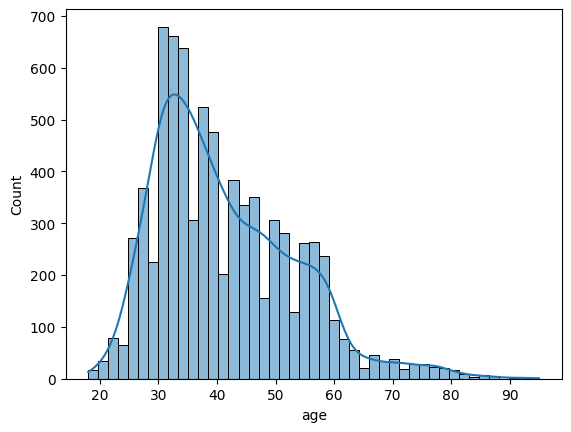

==== balance histogram ====


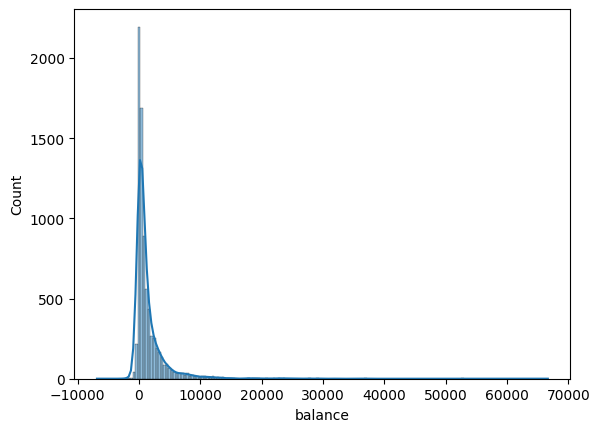

==== campaign histogram ====


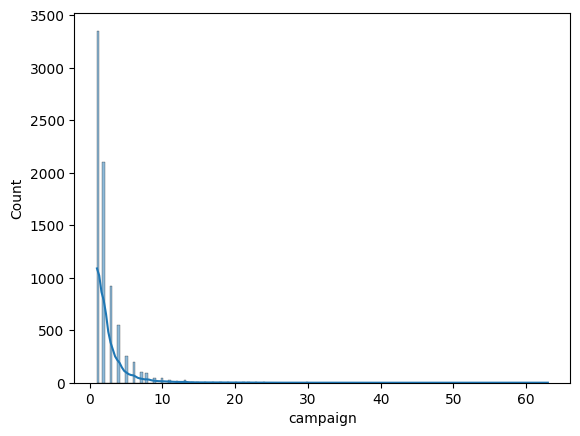

==== pdays histogram ====


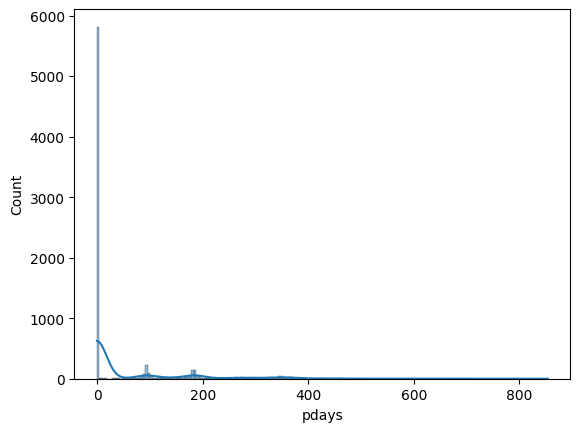

In [58]:
for i in df.select_dtypes(include='number'):
    print(f"==== {i} histogram ====")
    sns.histplot(data=df[i], kde=True)
    plt.show()

Cardinality of Categorical Value

==== job bar chart ====


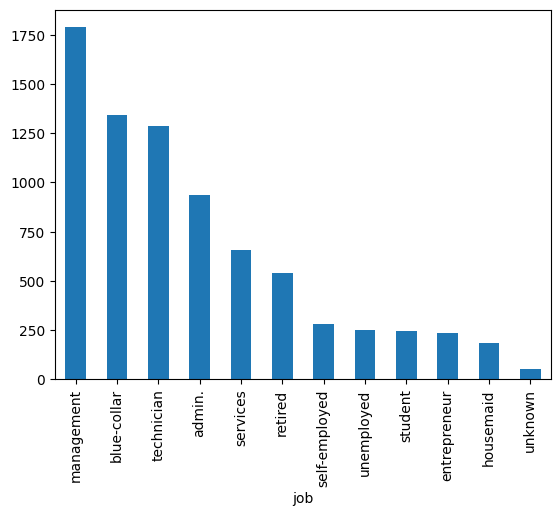

==== housing bar chart ====


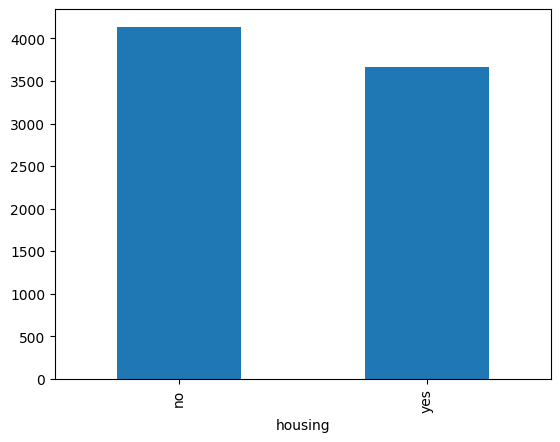

==== loan bar chart ====


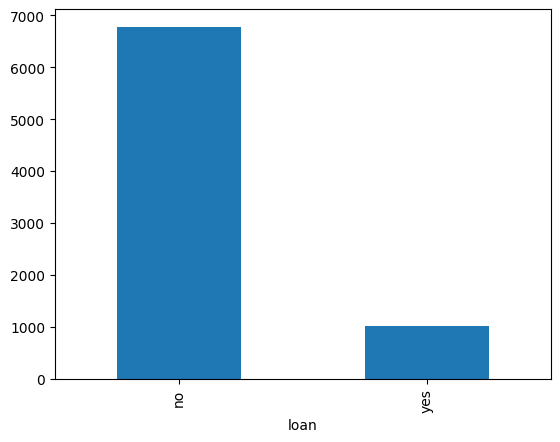

==== contact bar chart ====


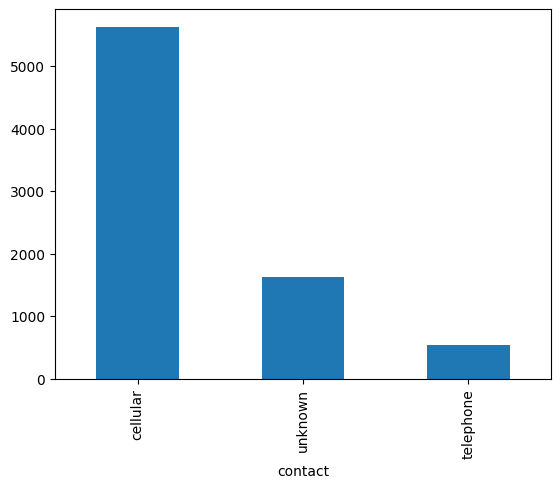

==== month bar chart ====


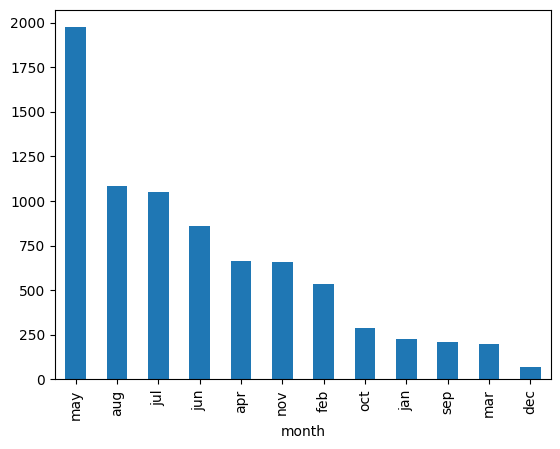

==== poutcome bar chart ====


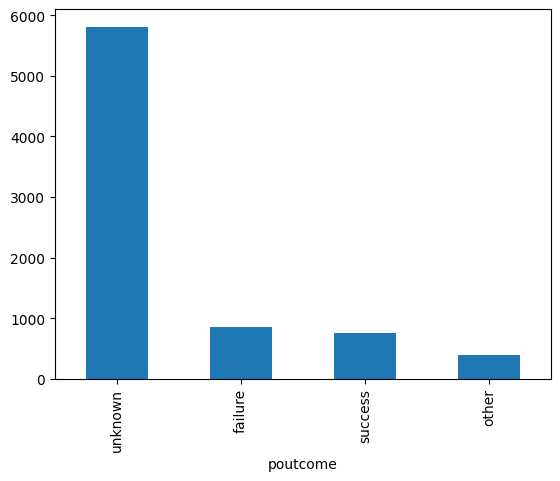

==== deposit bar chart ====


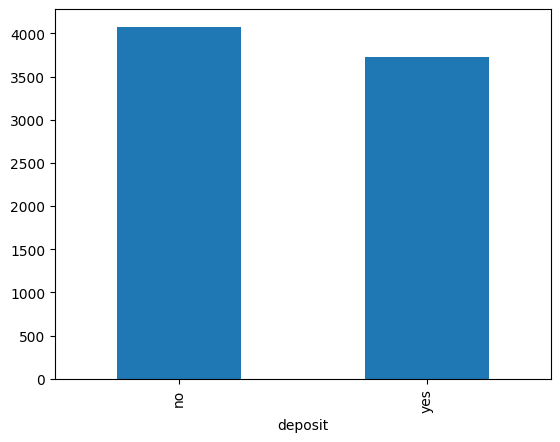

In [59]:
for i in df.select_dtypes(include='str'):
    print(f"==== {i} bar chart ====")
    df[i].value_counts().plot(kind='bar')
    plt.show()

Outlier Values

==== age boxplot ====


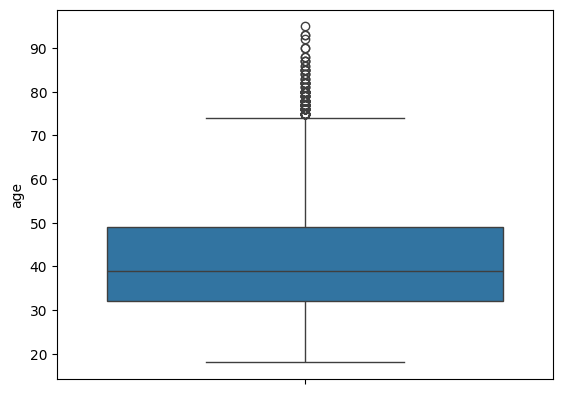

==== balance boxplot ====


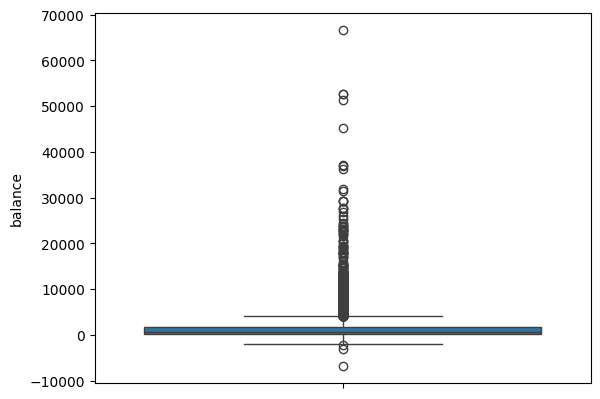

==== campaign boxplot ====


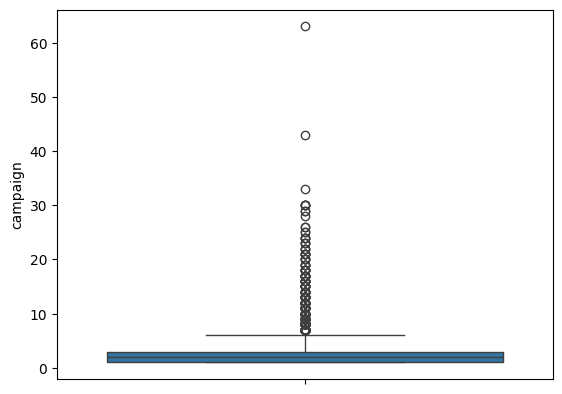

==== pdays boxplot ====


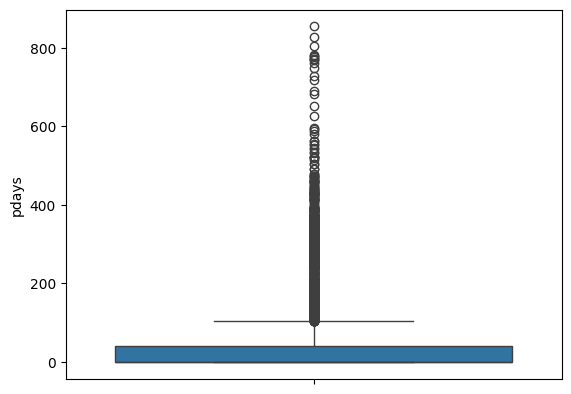

In [60]:
for i in df.select_dtypes(include='number'):
    print(f"==== {i} boxplot ====")
    sns.boxplot(data=df[i])
    plt.show()

In [61]:
for i in df.select_dtypes(include='number'):
    q1 =  df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + iqr * 1.5
    lower_bound = q1 - iqr * 1.5

    print(f"==== {i} Outlier ====")
    print(f"{i} column upper bound: {upper_bound}")
    print(f"{i} column lower bound: {lower_bound}")
    print(f"Total upper outlier in column {i}: {df[(df[i]>upper_bound)].shape[0]}")
    print(f"Total lower outlier in column {i}: {df[(df[i]<lower_bound)].shape[0]}\n")

==== age Outlier ====
age column upper bound: 74.5
age column lower bound: 6.5
Total upper outlier in column age: 121
Total lower outlier in column age: 0

==== balance Outlier ====
balance column upper bound: 4020.5
balance column lower bound: -2207.5
Total upper outlier in column balance: 733
Total lower outlier in column balance: 3

==== campaign Outlier ====
campaign column upper bound: 6.0
campaign column lower bound: -2.0
Total upper outlier in column campaign: 429
Total lower outlier in column campaign: 0

==== pdays Outlier ====
pdays column upper bound: 104.0
pdays column lower bound: -64.0
Total upper outlier in column pdays: 1432
Total lower outlier in column pdays: 0



## **Section 4. Exploratory Data Analysis (EDA)**

> 🎯 *Tujuan:* Menggali pola dan hubungan dalam data training untuk membangun intuisi sebelum masuk ke tahap modeling.

**5.1 Univariate Analysis**
- Distribusi target
- Distribusi fitur numerik
- Distribusi fitur kategorikal

> 🎯 *Tujuan:* Memahami karakteristik tiap variabel secara individual, termasuk seberapa seimbang distribusi target.

**5.2 Bivariate Analysis (terhadap Target)**

> 🎯 *Tujuan:* Mencari pola hubungan antara tiap fitur dengan target, untuk menjawab langsung Problem Statement di Section 1.2.

> 📌 Ini bagian paling penting untuk menjawab Problem Statement di Section 1.2 — cari pola antara tiap fitur dengan target, bukan sekadar plot tanpa insight.

**5.3 Correlation & Multicollinearity Check**

> 🎯 *Tujuan:* Mengecek hubungan antar fitur untuk mendeteksi multikolinearitas yang bisa mengganggu interpretasi model nanti.

**5.4 Multivariate / Interaction Analysis (opsional)**

> 🎯 *Tujuan:* Menelusuri interaksi antara beberapa fitur sekaligus untuk pola yang lebih kompleks dari yang bisa ditangkap analisis dua arah.

## **Section 5. Data Preparation**

> 🎯 *Tujuan:* Mengubah data mentah menjadi bentuk siap pakai untuk pemodelan (numerik, terskala, tanpa kategori yang belum di-encode).

**5.1 Initialization**
- Initialization function
- Define Feature and Target

> 🎯 *Tujuan:* Menyiapkan fungsi bantu dan mendefinisikan mana kolom fitur (X) dan target (y) sebelum transformasi dimulai.

**5.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset)**

> 🎯 *Tujuan:* Membagi data `Seen` menjadi training dan testing untuk keperluan pengembangan dan evaluasi model.

**5.3 Handling Imbalanced Data (jika relevan)**

> 🎯 *Tujuan:* Menangani ketimpangan proporsi kelas target supaya model tidak bias ke kelas mayoritas.

> 📌 Cek proporsi kelas target di Section 5.1. Kalau timpang (misal 90:10), pertimbangkan strategi seperti class_weight, SMOTE, atau undersampling — **tapi ingat, teknik resampling hanya boleh diterapkan pada data training**, tidak pernah pada data testing/unseen, supaya evaluasi tetap realistis.

**5.4 Data Transformation (Feature Engineering)**

> 🎯 *Tujuan:* Melakukan encoding, scaling, atau transformasi lain agar data sesuai kebutuhan algoritma yang dipakai.

**5.5 Feature Selection**

> 🎯 *Tujuan:* Memilih fitur yang paling relevan/berkontribusi untuk mengurangi noise dan risiko overfitting.

**5.6 Overview**

> 🎯 *Tujuan:* Merangkum hasil akhir data preparation (bentuk data final) sebelum masuk ke tahap Model Development.

## **Section 6. Model Development**

> 🎯 *Tujuan:* Membangun, membandingkan, dan menyempurnakan model machine learning menggunakan data.

**6.1 Initialization**
- Initialization Function
- Create Custom Metrics
- Define Cross-Validation Strategy
- Create a workflow of the experiment

> 🎯 *Tujuan:* Menyiapkan fungsi metrik custom dan strategi cross-validation yang dipakai konsisten di seluruh eksperimen model.

> 📌 Tentukan strategi CV secara eksplisit (misal `StratifiedKFold` untuk klasifikasi dengan target tidak seimbang) dan simpan `RANDOM_STATE` yang sama dari Section 0. Ingat prinsip **CV-first**: bandingkan model lewat cross-validation dulu, baru evaluasi akhir di data testing — jangan sebaliknya.

**6.2 Developing the Model Pipeline**

> 🎯 *Tujuan:* Merangkai seluruh langkah preprocessing dan model ke dalam satu objek Pipeline yang konsisten dipakai ulang.

> 📌 Gunakan `Pipeline`/`ColumnTransformer` dari scikit-learn supaya seluruh langkah preprocessing (imputasi, encoding, scaling) ikut ter-*fit* hanya pada data training di setiap fold — ini mencegah data leakage antara fold CV.

**6.3 Model Benchmarking (Comparing model base performance)**

> 🎯 *Tujuan:* Membandingkan performa dasar beberapa algoritma (tanpa tuning) untuk memilih kandidat terbaik yang layak dituning lebih lanjut.

**6.4 Tune Model**

> 🎯 *Tujuan:* Mengoptimalkan hyperparameter dari model kandidat terbaik hasil benchmarking untuk meningkatkan performa.

**6.5 Analyze Model**
- Evaluate model on data testing
- Confusion Matrix / Threshold Analysis (Classification) atau Residual Analysis (Regression)
- Learning Curve Inspection

> 🎯 *Tujuan:* Mengevaluasi performa model secara mendalam di luar satu angka metrik utama, termasuk mengecek tanda overfitting/underfitting.

**6.6 Model Calibration (Classification Only)**

> 🎯 *Tujuan:* Menyesuaikan output probabilitas model supaya lebih merepresentasikan kemungkinan sebenarnya, penting saat threshold dipakai untuk keputusan bisnis.

**6.7 Model Explanation and Interpretation**
- Feature Importance (Tree Based Model) / Coefficient Regression (Regression Based Model)
- SHAP Value identification
- Counterfactual Analysis

> 🎯 *Tujuan:* Menjelaskan bagaimana model mengambil keputusan — penting untuk membangun kepercayaan stakeholder bisnis terhadap model.

## **Section 7. Model Deployment**

> 🎯 *Tujuan:* Menyiapkan model terlatih agar bisa dipakai di luar notebook, lengkap dengan dokumentasi teknis yang diperlukan.

**7.1 Export Model (joblib/pickle)**

> 🎯 *Tujuan:* Menyimpan pipeline terlatih ke dalam file yang bisa dimuat ulang tanpa perlu melatih ulang dari awal.

> 📌 Minimal, export pipeline lengkap (bukan cuma model) dengan `joblib.dump()` supaya preprocessing dan model tetap satu paket saat dipakai ulang.

**7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

> 🎯 *Tujuan:* Mendokumentasikan hal teknis yang perlu diperhatikan tim lain saat model dipakai di lingkungan produksi.

## **Section 8. Model Implementation**

> 🎯 *Tujuan:* Menjelaskan cara pakai model di dunia nyata, batasannya, dan dampak bisnisnya lewat simulasi.

**8.1 How to implement the model?**

> 🎯 *Tujuan:* Menjelaskan langkah teknis memakai model untuk melakukan prediksi pada data baru.

**8.2 What are the limitations of the model?**

> 🎯 *Tujuan:* Mengakui batasan model secara jujur, termasuk skenario di mana prediksinya kurang bisa diandalkan.

**8.3 Business Calculation (Simulation using unseen data)**

> 🎯 *Tujuan:* Mensimulasikan dampak bisnis dari penggunaan model, memakai data `unseen` yang belum pernah dilihat selama proses modeling.

> 📌 Ini saatnya `unseen` data dipakai. Kaitkan hasil simulasi dengan metrik bisnis yang kamu tetapkan di Section 1.5 — misalnya, hitung estimasi kerugian akibat False Negative vs biaya operasional akibat False Positive, sesuai threshold yang dipilih.

## **Section 9. Conclusion and Recommendation**

> 🎯 *Tujuan:* Merangkum keseluruhan proyek dan menerjemahkan hasil teknis kembali ke bahasa yang dipahami stakeholder bisnis.

**9.1 Conclusion**
- Conclusion (Model)
- Conclusion (Business)

> 🎯 *Tujuan:* Merangkum temuan utama dari sisi performa model dan sisi dampak bisnis, menjawab kembali Goals di Section 1.3.

**9.2 Recommendation**
- Recommendation (Model)
- Recommendation (Business)

> 🎯 *Tujuan:* Memberikan rekomendasi tindak lanjut konkret berdasarkan temuan proyek, baik dari sisi teknis maupun bisnis.